# Generated and reconstructed $t'$

Exclusive SIMC events only. Generated $t'=-t_i-t_{\min}(Q_i^2,W_i)$; reconstructed $t'=t-t_{\min}$. Curves show the fraction of total simulation weight in each bin.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import uproot

FILES = {
    "KinC x36_4": Path("/volatile/hallc/nps/singhav/nps_smearing/smear_x36_4/smearing_output/KinC_x36_4/root/simc_pi0_analysis_output_smeared.root"),
    "KinC x36_5_407": Path("/volatile/hallc/nps/singhav/nps_smearing/smear_x36_5_407/smearing_output/KinC_x36_5_407/root/simc_pi0_analysis_output_smeared.root"),
}
M_PROTON, M_PI0 = 0.9382720813, 0.1349768  # GeV


def load_tprime(path):
    with uproot.open(path) as root_file:
        a = root_file["simulation"].arrays(
            ["Q2i", "Wi", "ti", "t", "tmin", "full_weight", "is_exclusive"], library="np"
        )
    keep = (a["is_exclusive"] == 1) & (a["Q2i"] > 0) & (a["Wi"] > M_PROTON + M_PI0)
    keep &= np.isfinite(a["ti"]) & np.isfinite(a["t"]) & np.isfinite(a["tmin"])
    keep &= np.isfinite(a["full_weight"]) & (a["full_weight"] > 0)
    q2, w = a["Q2i"][keep], a["Wi"][keep]
    e_gamma = (w**2 - M_PROTON**2 - q2) / (2 * w)
    e_pi = (w**2 + M_PI0**2 - M_PROTON**2) / (2 * w)
    tmin_gen = M_PI0**2 - q2 - 2 * e_gamma * e_pi + 2 * np.sqrt(e_gamma**2 + q2) * np.sqrt(e_pi**2 - M_PI0**2)
    generated = -a["ti"][keep] - tmin_gen  # SIMC ti is positive -t
    reconstructed = a["t"][keep] - a["tmin"][keep]
    weight = a["full_weight"][keep]
    return generated, reconstructed, weight / weight.sum()


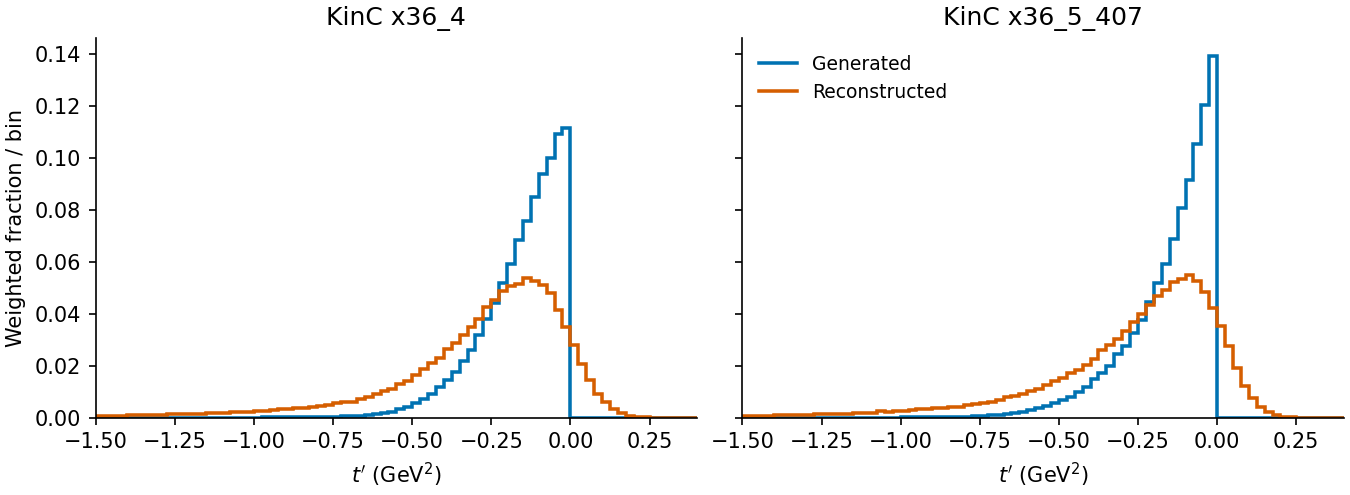

In [7]:
bins = np.linspace(-1.5, 0.4, 77)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), sharex=True, sharey=True, constrained_layout=True)
for ax, (label, path) in zip(axes, FILES.items()):
    generated, reconstructed, weight = load_tprime(path)
    for values, name, color in [(generated, "Generated", "#0072B2"), (reconstructed, "Reconstructed", "#D55E00")]:
        counts, _ = np.histogram(values, bins=bins, weights=weight)
        ax.stairs(counts, bins, label=name, color=color, linewidth=1.7)
    ax.set(title=label, xlim=(bins[0], bins[-1]), xlabel=r"$t'$ (GeV$^2$)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Weighted fraction / bin")
axes[1].legend(frameon=False, fontsize=9)
plt.show()


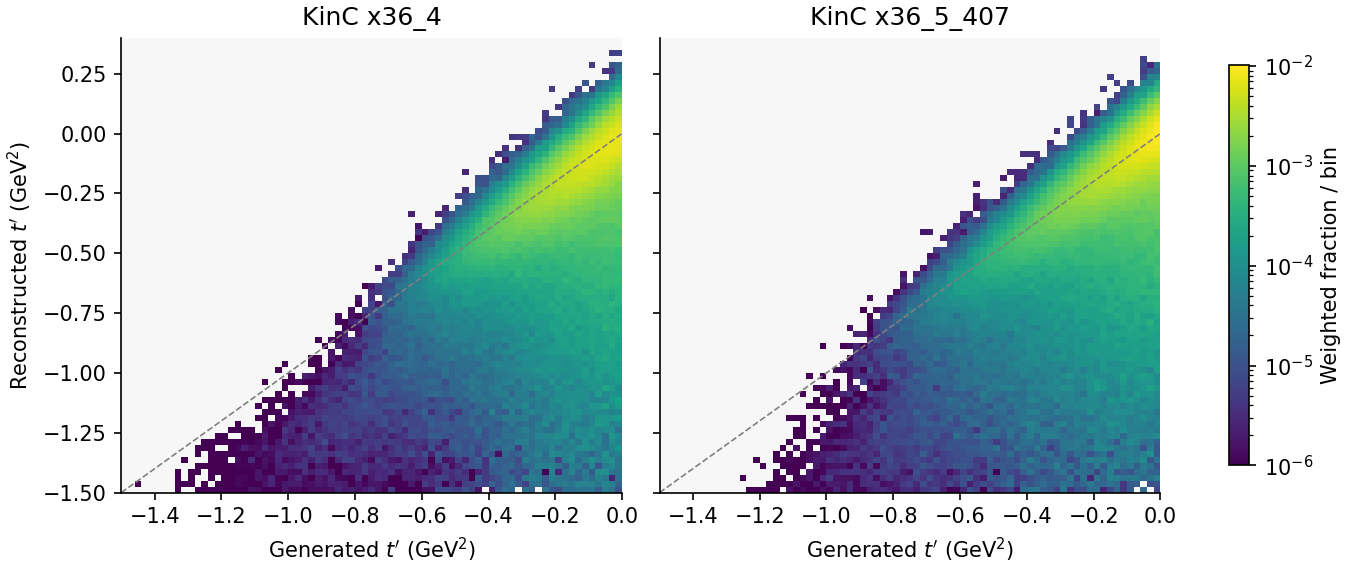

In [8]:
from matplotlib.colors import LogNorm

x_edges = np.linspace(-1.5, 0.0, 76)
y_edges = np.linspace(-1.5, 0.4, 77)
distributions = []
for label, path in FILES.items():
    generated, reconstructed, weight = load_tprime(path)
    hist, _, _ = np.histogram2d(
        generated, reconstructed, bins=(x_edges, y_edges), weights=weight
    )
    distributions.append((label, hist))

fig, axes = plt.subplots(
    1, 2, figsize=(9, 3.8), sharex=True, sharey=True, constrained_layout=True
)
norm = LogNorm(vmin=1e-6, vmax=max(hist.max() for _, hist in distributions))
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#F7F7F7")
for ax, (label, hist) in zip(axes, distributions):
    mesh = ax.pcolormesh(x_edges, y_edges, hist.T, cmap=cmap, norm=norm, shading="flat")
    ax.plot([-1.5, 0], [-1.5, 0], color="0.5", linewidth=0.8, linestyle="--")
    ax.set(title=label, xlabel=r"Generated $t'$ (GeV$^2$)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel(r"Reconstructed $t'$ (GeV$^2$)")
fig.colorbar(mesh, ax=axes, label="Weighted fraction / bin", shrink=0.88)
plt.show()
